---
jupyter: ir
---


In [1]:
# Instalação de pacotes necessários
pkgs <- c(
  "tidymodels",
  'glmnet',
  "rstanarm"
)

instalar <- pkgs[!pkgs %in% installed.packages()[, "Package"]]

if (length(instalar) > 0) {
  install.packages(instalar)
}

In [2]:
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() mask

In [3]:
#
set.seed(42)

In [4]:
loan <- read_csv("../data/Loan/loan_approval_dataset.csv") |>
  clean_names()

Rows: 4269 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): education, self_employed, loan_status
dbl (10): loan_id, no_of_dependents, income_annum, loan_amount, loan_term, c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
#preprocessamento
loan <- janitor::clean_names(loan)

loan <- loan |>
  dplyr::filter(residential_assets_value >= 0)

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>."


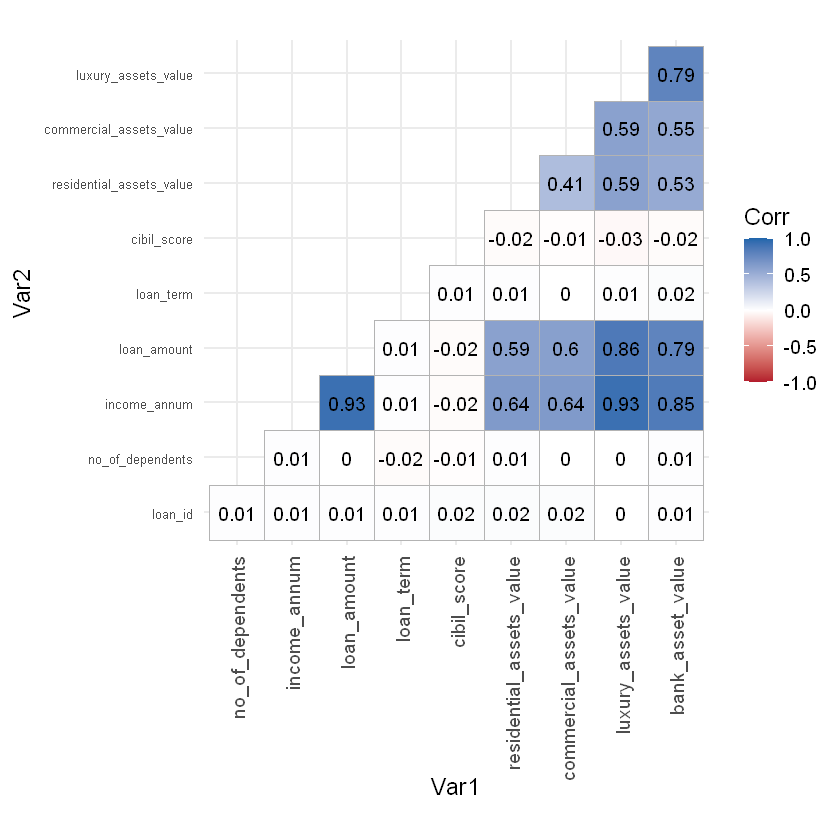

In [6]:
loan_num <- loan |>
  dplyr::select(where(is.numeric))

cor_matrix <- cor(
  loan_num,
  use = "complete.obs",
  method = "pearson"
)

ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = TRUE,
  lab_size = 4,
  colors = c("#b2182b", "white", "#2166ac"),
  outline.col = "gray70"
) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5
    ),
    axis.text.y = element_text(size = 8)
  )

In [7]:
vars_categoricas <- c(
  "education",
  "self_employed"
)

vars_numericas <- c(
  "no_of_dependents",
  "income_annum",
  "loan_amount",
  "loan_term",
  "cibil_score",
  "residential_assets_value",
  "commercial_assets_value",
  "luxury_assets_value",
  "bank_asset_value"
)

# One-Hot Encoding
loan_encoded <- loan %>%
  mutate(
    education = factor(education),
    self_employed = factor(self_employed)
  ) %>%
  fastDummies::dummy_cols(
    select_columns = vars_categoricas,
    remove_selected_columns = TRUE,
    remove_first_dummy = TRUE
  )

# Padronização (Standardization)
#loan_encoded[vars_numericas] <- lapply(
#  loan_encoded[vars_numericas],
#  function(x) as.numeric(as.character(x))
#)
#loan_encoded[vars_numericas] <- scale(loan_encoded[vars_numericas])

In [8]:
#remodendo loan id
loan_encoded <- loan_encoded |>
  dplyr::select(-loan_id)

loan_encoded$loan_status <- ifelse(
  loan_encoded$loan_status %in% c("Approved", 1, "1"),
  1, 0
)
loan_encoded$loan_status <- as.factor(loan_encoded$loan_status)


split <- initial_split(
  loan_encoded,
  prop   = 0.75,
  strata = loan_status
)

train_data <- training(split)
test_data  <- testing(split)

In [9]:
count(train_data, loan_status)
count(test_data, loan_status)

loan_status,n
<fct>,<int>
0,1200
1,1980


loan_status,n
<fct>,<int>
0,401
1,660


para o frequentista
- Modelo geral (tudo) OK
- Modelo apenas com score Ok
- Modelo sem score ok
- Modelo com remoção das feats correlacionadas ok
- Modelo com PCA
- Modelo com regularização para selecionar feats (glmnet) ok

In [10]:
rec_lasso <- recipe(loan_status ~ ., data = train_data) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

logit_lasso_spec <- logistic_reg(
  penalty = tune(),
  mixture = 1        # LASSO puro
) %>%
  set_engine("glmnet")

wf_lasso <- workflow() %>%
  add_recipe(rec_lasso) %>%
  add_model(logit_lasso_spec)


folds <- vfold_cv(train_data, v = 5)

grid_lambda <- grid_regular(penalty(), levels = 50)

lasso_res <- tune_grid(
  wf_lasso,
  resamples = folds,
  grid = grid_lambda,
  metrics = metric_set(roc_auc)
)  
best_lambda <- select_best(lasso_res, metric = "roc_auc")
best_lambda

penalty,.config
<dbl>,<chr>
0.0008685114,pre0_mod35_post0


In [11]:
final_lasso_wf <- finalize_workflow(
  wf_lasso,
  best_lambda
)

final_lasso_fit <- fit(
  final_lasso_wf,
  data = train_data
)

lasso_coefs <- final_lasso_fit %>%
  extract_fit_parsnip() %>%
  tidy()

vars_selected <- lasso_coefs %>%
  filter(term != "(Intercept)") %>%
  filter(estimate != 0) %>%
  mutate(abs_est = abs(estimate))
vars_importance <- vars_selected %>%
  mutate(importance = abs_est / sum(abs_est)) %>%
  select(variable = term, importance) %>%
  arrange(desc(importance))

vars_importance

variable,importance
<chr>,<dbl>
cibil_score,0.540896692
income_annum,0.164836108
loan_amount,0.137832359
loan_term,0.108517830
bank_asset_value,0.014808588
luxury_assets_value,0.010021713
commercial_assets_value,0.008276973
no_of_dependents,0.006634555
self_employed_Yes,0.004926413


In [12]:
not_best_vars <- vars_importance %>%
  dplyr::filter(importance < 0.10) %>%
  dplyr::pull(variable)

In [13]:
#modelo geral
rec_all <- recipe(loan_status ~ ., data = train_data)

# score only
rec_score_only <- recipe(
  loan_status ~ cibil_score,
  data = train_data
)

#resultado da regularização
rec_feat_select <- recipe(
  loan_status ~ .,
  data = train_data
) %>%
  step_rm(all_of(not_best_vars))

#no score
rec_no_score <- recipe(
  loan_status ~ .,
  data = train_data
) |>
  step_rm(cibil_score)

# Removendo alta correlação
rec_no_assets <- recipe(
  loan_status ~ .,
  data = train_data
) |>
  step_rm(luxury_assets_value, bank_asset_value)



#com pca
rec_pca <- recipe(
  loan_status ~ .,
  data = train_data
) |>
  step_normalize(all_numeric_predictors()) |>
  step_pca(
    all_numeric_predictors(),
    threshold = 0.95
  )

In [14]:
log_spec <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")

In [15]:
wf_logit <- workflow_set(
  preproc = list(
    all_features = rec_all,
    score_only   = rec_score_only,
    no_score     = rec_no_score,
    no_assets    = rec_no_assets,
    feat_select  = rec_feat_select
  ),
  models = list(
    logit = log_spec
  )
)


wf_pca <- workflow_set(
  preproc = list(
    pca = rec_pca
  ),
  models = list(
    logit = log_spec
  )
)

In [16]:
wf_set <- rbind(
  wf_logit,
  wf_pca
)

In [17]:
wf_fitted <- wf_set %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data)
    )
  )

In [18]:
library(dplyr)
library(purrr)
library(yardstick)

preds <- wf_fitted %>%
  mutate(
    preds = purrr::map(
      fit,
      ~{
        prob_tbl <- predict(.x, test_data, type = "prob")

        tibble(
          truth = test_data$loan_status,
          class = predict(.x, test_data, type = "class")$.pred_class,
          prob  = prob_tbl$.pred_1
        )
      }
    )
  ) %>%
  select(wflow_id, preds)

preds <- preds %>%
  tidyr::unnest(preds)

In [19]:
metrics_table <- preds %>%
  group_by(wflow_id) %>%
  summarise(

    # 📌 classificação geral
    accuracy = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    # 📌 ranking / separação
    roc_auc = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    # 📌 sensibilidade / especificidade
    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    # 📌 custo de erro (crédito)
    precision = precision_vec(truth, class),
    npv = npv_vec(truth, class),

    # 📌 equilíbrio
    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    # 📌 robustez estatística
    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    # 📌 equilíbrio sens/spec
    gmean = sqrt(sens_vec(truth, class) * spec_vec(truth, class)),

    .groups = "drop"
  )

In [20]:
metrics_table

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9293120,0.9240988,0.9762790,4.0469713,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520
feat_select_logit,0.9283695,0.9233413,0.9762979,4.0239070,0.90274314,0.9439394,0.9072682,0.9410876,0.90500000,0.90364453,0.84751192,0.84751875,0.9231115
no_assets_logit,0.9293120,0.9240988,0.9761845,4.0291824,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520
no_score_logit,0.6145146,0.5042148,0.5974420,0.8170664,0.05236908,0.9560606,0.4200000,0.6241345,0.09312639,0.06348247,0.01017766,0.01928834,0.2237588
pca_logit,0.9227144,0.9163493,0.9736001,3.8883426,0.89027431,0.9424242,0.9037975,0.9339339,0.89698492,0.89294647,0.83515043,0.83521119,0.9159782
score_only_logit,0.9274270,0.9235623,0.9669104,3.4150647,0.90773067,0.9393939,0.9009901,0.9436834,0.90434783,0.90637450,0.84588292,0.84589817,0.9234266


In [21]:
extract_model_summary <- function(wf_fit) {
  model_fit <- workflows::extract_fit_parsnip(wf_fit)

  if (inherits(model_fit$fit, "glm")) {
    return(summary(model_fit$fit))
  }

  if (inherits(model_fit$fit, "lognet")) {
    return(model_fit$fit)
  }

  NULL
}

In [22]:
model_summaries <- wf_fitted %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
  
for (i in seq_len(nrow(model_summaries))) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -1.102e+01  4.946e-01 -22.289  < 2e-16 ***
no_of_dependents         -3.727e-02  3.980e-02  -0.936    0.349    
income_annum             -6.179e-07  1.032e-07  -5.985 2.17e-09 ***
loan_amount               1.380e-07  2.061e-08   6.693 2.18e-11 ***
loan_term                -1.508e-01  1.302e-02 -11.582  < 2e-16 ***
cibil_score               2.452e-02  9.535e-04  25.716  < 2e-16 ***
residential_assets_value  2.674e-09  1.353e-08   0.198    0.843    
commercial_assets_value   2.114e-08  1.970e-08   1.073    0.283    
luxury_assets_value       2.891e-08  2.024e-08   1.429    0.153    
bank_asset_value          6.085e-08  3.833e-08   1.588    0.112    
`education_Not Graduate` -7.937e-02  1.351e-01  -0.587    0.557    
self_employed_Yes         9.816e-02  1.352e-01   0.726    0.468

In [23]:
metrics_table

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9293120,0.9240988,0.9762790,4.0469713,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520
feat_select_logit,0.9283695,0.9233413,0.9762979,4.0239070,0.90274314,0.9439394,0.9072682,0.9410876,0.90500000,0.90364453,0.84751192,0.84751875,0.9231115
no_assets_logit,0.9293120,0.9240988,0.9761845,4.0291824,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520
no_score_logit,0.6145146,0.5042148,0.5974420,0.8170664,0.05236908,0.9560606,0.4200000,0.6241345,0.09312639,0.06348247,0.01017766,0.01928834,0.2237588
pca_logit,0.9227144,0.9163493,0.9736001,3.8883426,0.89027431,0.9424242,0.9037975,0.9339339,0.89698492,0.89294647,0.83515043,0.83521119,0.9159782
score_only_logit,0.9274270,0.9235623,0.9669104,3.4150647,0.90773067,0.9393939,0.9009901,0.9436834,0.90434783,0.90637450,0.84588292,0.84589817,0.9234266


In [24]:
fits_vif <- wf_fitted %>%
  dplyr::filter(
    wflow_id %in% c(
      "all_features_logit",
      "no_assets_logit",
      "no_score_logit",
      "feat_select_logit"
    )
  )

#apenas os modelos sem PCA...

In [25]:
library(car)

calc_vif <- function(wf_fit) {
  wf_fit %>%
    workflows::extract_fit_parsnip() %>%
    pluck("fit") %>%      # objeto glm
    car::vif()
}

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )

Carregando pacotes exigidos: carData

Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4


Anexando pacote: 'car'


O seguinte objeto é mascarado por 'package:rstanarm':

    logit


O seguinte objeto é mascarado por 'package:dplyr':

    recode


O seguinte objeto é mascarado por 'package:purrr':

    some




In [26]:
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

In [27]:
vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )
vif_summary

wflow_id,max_vif,mean_vif
<chr>,<dbl>,<dbl>
all_features_logit,18.147188,4.146099
feat_select_logit,8.031679,3.979695
no_assets_logit,8.585693,2.789998
no_score_logit,17.041102,4.216524


In [28]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

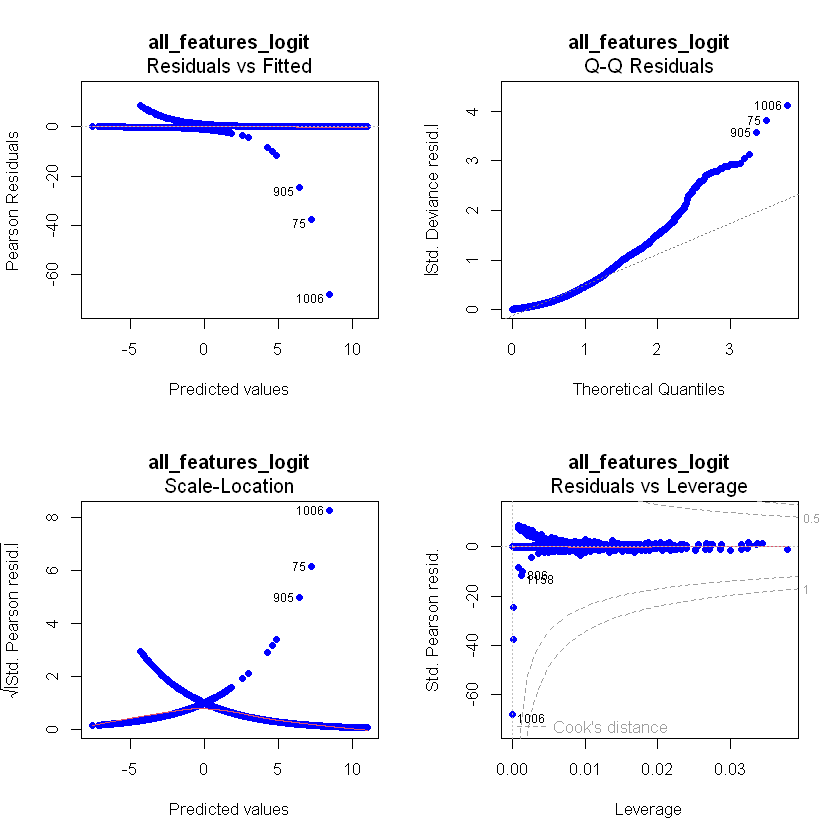

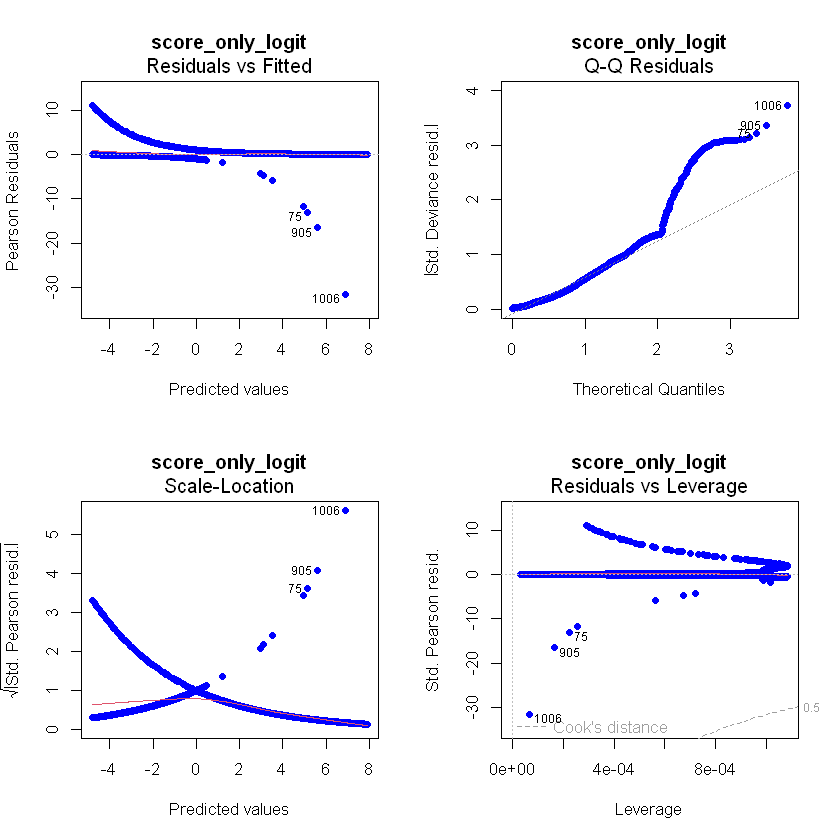

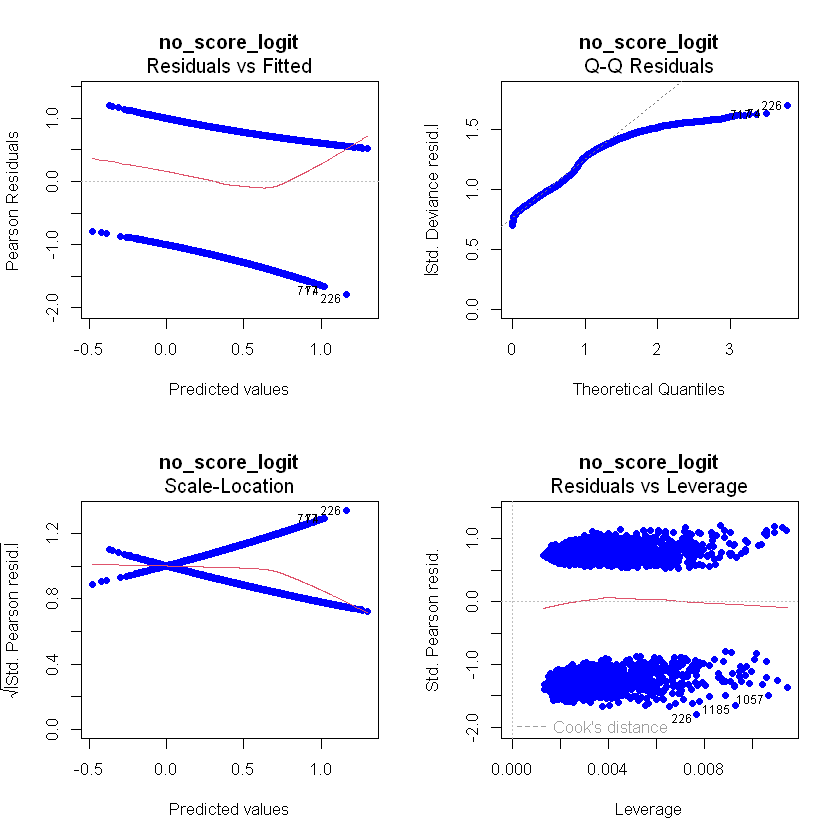

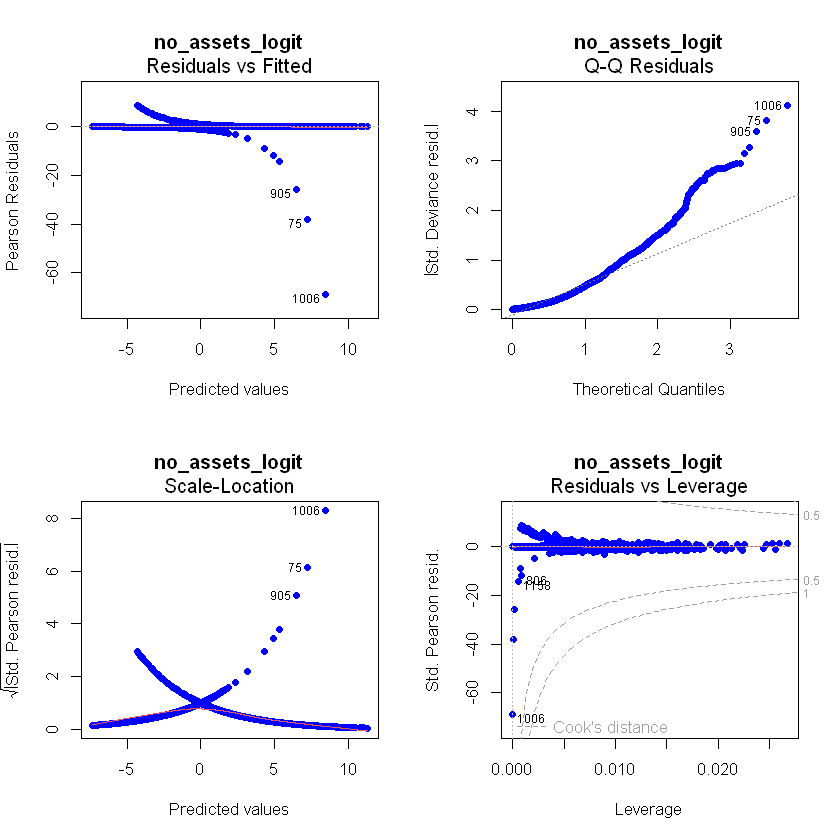

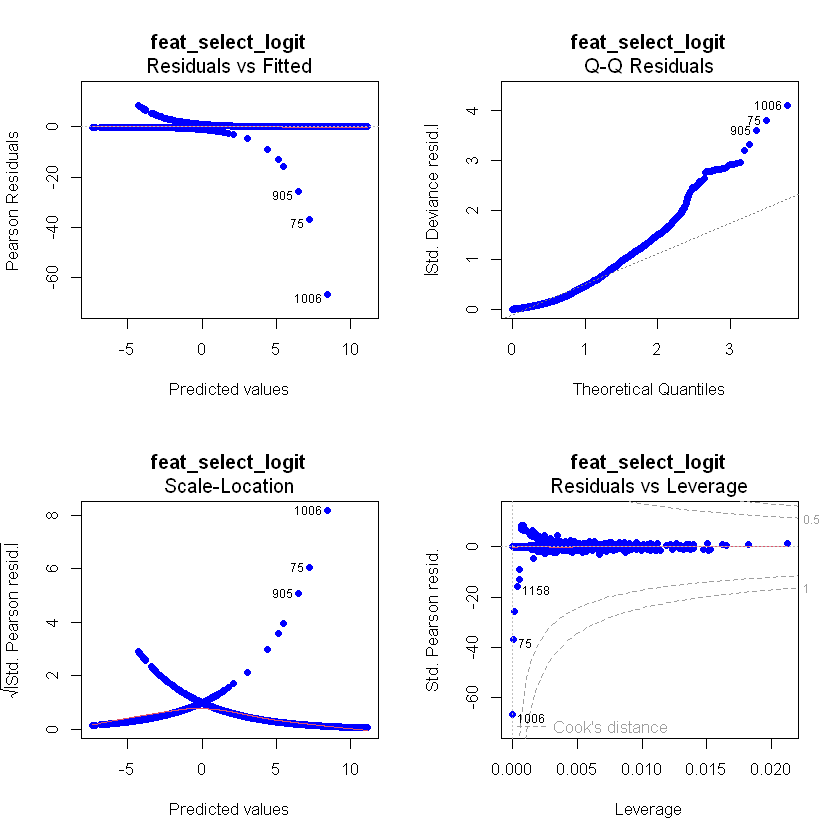

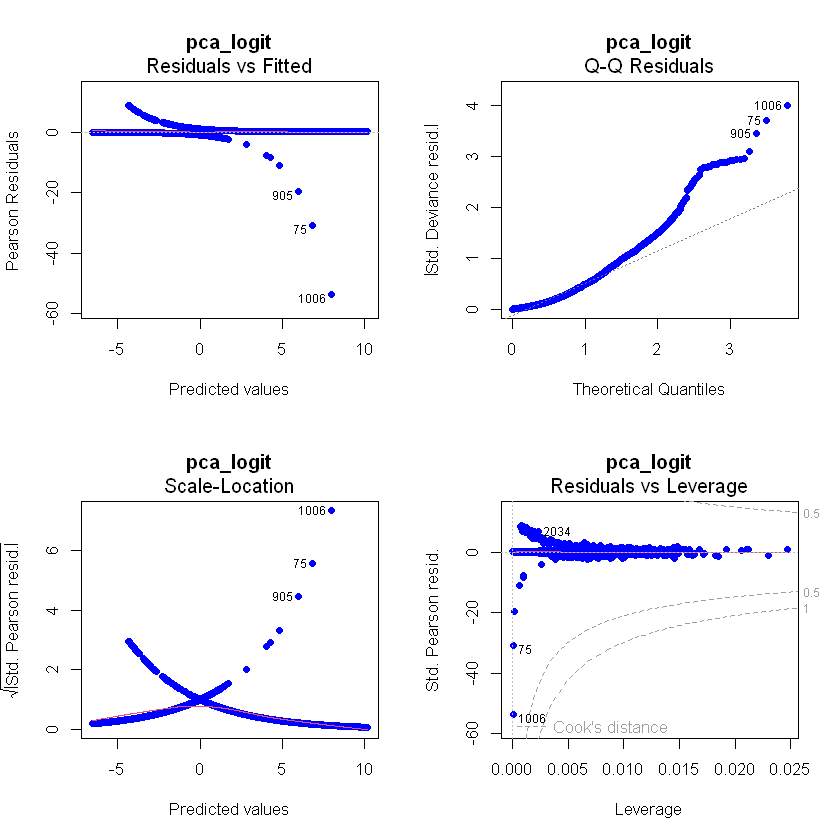

In [29]:
purrr::walk2(
  wf_fitted$fit,
  wf_fitted$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)

all_features_logit não é adequado para inferência, apesar do ótimo desempenho.
no_assets_logit reduz drasticamente a colinearidade sem perda preditiva.
feat_select_logit também melhora o VIF, mas menos que no_assets_logit.

In [30]:
library(dplyr)

model_summary <- metrics_table %>%
  select(
    wflow_id,
    accuracy,
    bal_accuracy,
    roc_auc,
    f1
  ) %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )

In [31]:
library(dplyr)

model_summary <- metrics_table %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )

In [32]:
model_summary

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9293120,0.9240988,0.9762790,4.0469713,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520,18.147188,4.146099
feat_select_logit,0.9283695,0.9233413,0.9762979,4.0239070,0.90274314,0.9439394,0.9072682,0.9410876,0.90500000,0.90364453,0.84751192,0.84751875,0.9231115,8.031679,3.979695
no_assets_logit,0.9293120,0.9240988,0.9761845,4.0291824,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520,8.585693,2.789998
no_score_logit,0.6145146,0.5042148,0.5974420,0.8170664,0.05236908,0.9560606,0.4200000,0.6241345,0.09312639,0.06348247,0.01017766,0.01928834,0.2237588,17.041102,4.216524
pca_logit,0.9227144,0.9163493,0.9736001,3.8883426,0.89027431,0.9424242,0.9037975,0.9339339,0.89698492,0.89294647,0.83515043,0.83521119,0.9159782,NA,NA
score_only_logit,0.9274270,0.9235623,0.9669104,3.4150647,0.90773067,0.9393939,0.9009901,0.9436834,0.90434783,0.90637450,0.84588292,0.84589817,0.9234266,NA,NA


bom, no_score aponta que o cibil_score é importante
--- Modelos com melhores desempenhos geral
all_features_logit
feat_select_logit
no_assets_logit
- ROC AUC ~ 0.976
- F1 ~ 0.905–0.906
all_features_logit
-> Max VIF = 18.15 → forte colinearidade
feat_select_logit
-> Max VIF = 8.03 → redução significativa
no_assets_logit
-> melhor equilíbrio entre VIF (média menor) e performance

O PCA não aplica VIF e tem uma queda na performance

In [33]:
library(tidymodels)
library(rstanarm)

In [34]:
library(rstanarm)

fit_bayes <- stan_glm(
  loan_status ~ . - luxury_assets_value - bank_asset_value,
  data = train_data,
  family = binomial(link = "logit"),
  prior = normal(0, 1),
  prior_intercept = normal(0, 5),
  chains = 4,
  iter = 2000,
  seed = 123
)


SAMPLING FOR MODEL 'bernoulli' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000294 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 2.94 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 3860.82 seconds (Warm-up)
Chain 1:                6271.74 seconds (Sampling)
Chain 1:                

Warning message:
"There were 21 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them."
Warning message:
"There were 1868 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 15. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded"
Warning message:
"There were 3 chains where the estimated Bayesian Fraction of Missing Information was low. See
https://mc-stan.org/misc/warnings.html#bfmi-low"
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"
Warning message:
"The largest R-hat is 4.2, indicating chains have not mixed.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#r-hat"
Warning message:
"Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
http

In [35]:
post_prob <- posterior_linpred(
  fit_bayes,
  newdata = test_data,
  transform = TRUE
)

prob_mean <- colMeans(post_prob)

Instead of posterior_linpred(..., transform=TRUE) please call posterior_epred(), which provides equivalent functionality.



In [36]:
pred_class <- ifelse(prob_mean > 0.5, "yes", "no") %>%
  factor(levels = levels(test_data$loan_status))

In [37]:
library(dplyr)

preds_bayes <- test_data %>%
  mutate(
    prob = prob_mean,
    class = factor(
      ifelse(prob >= 0.5, "1", "0"),
      levels = levels(loan_status)
    ),
    truth = loan_status,
    wflow_id = "bayes_logit"
  )

preds_bayes <- preds_bayes %>%
  mutate(wflow_id = "bayes_logit")

In [38]:
library(yardstick)
library(dplyr)

metrics_bayes <- preds_bayes %>%
  group_by(wflow_id) %>%
  summarise(

    # 📌 classificação geral
    accuracy = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    # 📌 ranking / separação
    roc_auc = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    # 📌 sensibilidade / especificidade
    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    # 📌 custo de erro (crédito)
    precision = precision_vec(truth, class),
    npv = npv_vec(truth, class),

    # 📌 equilíbrio
    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    # 📌 robustez estatística
    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    # 📌 equilíbrio sens/spec
    gmean = sqrt(
      sens_vec(truth, class) * spec_vec(truth, class)
    ),

    .groups = "drop"
  )

In [39]:
table(preds_bayes$class)


  0   1 
482 579 

In [40]:
library(car)

vif_bayes <- car::vif(fit_bayes)
vif_bayes

no_of_dependents             income_annum              loan_amount 
              1213.13666              13709.22092              12281.82238 
               loan_term              cibil_score residential_assets_value 
               983.28903                 47.53333                163.68411 
 commercial_assets_value `education_Not Graduate`        self_employed_Yes 
               356.99887                 15.78558                 27.96272

In [41]:
vif_summary <- tibble(
  max_vif  = max(vif_bayes, na.rm = TRUE),
  mean_vif = mean(vif_bayes, na.rm = TRUE)
)

In [42]:
metrics_bayes <- bind_cols(metrics_bayes, vif_summary)

In [43]:
metrics_all <- bind_rows(
  model_summary,   
  metrics_bayes
)

metrics_all

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9293120,0.9240988,0.9762790,4.0469713,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520,18.147188,4.146099
feat_select_logit,0.9283695,0.9233413,0.9762979,4.0239070,0.90274314,0.9439394,0.9072682,0.9410876,0.90500000,0.90364453,0.84751192,0.84751875,0.9231115,8.031679,3.979695
no_assets_logit,0.9293120,0.9240988,0.9761845,4.0291824,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520,8.585693,2.789998
no_score_logit,0.6145146,0.5042148,0.5974420,0.8170664,0.05236908,0.9560606,0.4200000,0.6241345,0.09312639,0.06348247,0.01017766,0.01928834,0.2237588,17.041102,4.216524
pca_logit,0.9227144,0.9163493,0.9736001,3.8883426,0.89027431,0.9424242,0.9037975,0.9339339,0.89698492,0.89294647,0.83515043,0.83521119,0.9159782,NA,NA
score_only_logit,0.9274270,0.9235623,0.9669104,3.4150647,0.90773067,0.9393939,0.9009901,0.9436834,0.90434783,0.90637450,0.84588292,0.84589817,0.9234266,NA,NA
bayes_logit,0.8765316,0.8885249,0.9483526,1.2155924,0.93765586,0.8393939,0.7800830,0.9568221,0.85164213,0.90124640,0.74742640,0.75671128,0.8871655,13709.220924,3199.937066


Warning message:
"The following arguments were unrecognized and ignored: pch, col, main"


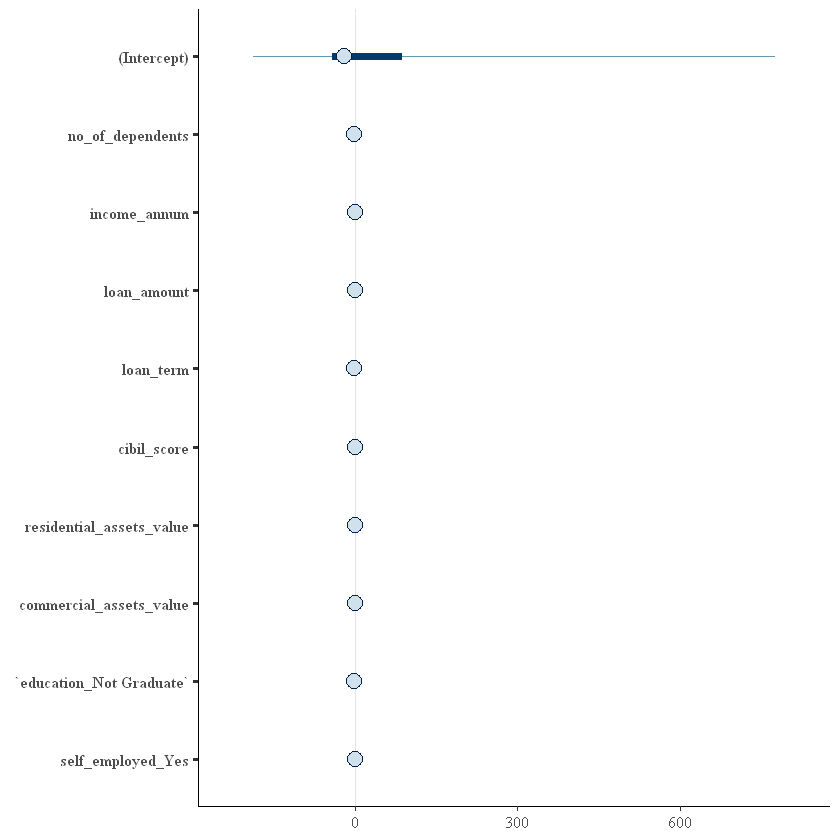

In [44]:
par(mfrow = c(2, 2))

plot(
  fit_bayes,
  pch = 19,
  col = "blue",
  main = "Bayesian Logistic Regression"
)

par(mfrow = c(1, 1))  # reset layout

This is bayesplot version 1.15.0

- Online documentation and vignettes at mc-stan.org/bayesplot

- bayesplot theme set to bayesplot::theme_default()

   * Does _not_ affect other ggplot2 plots

   * See ?bayesplot_theme_set for details on theme setting

Warning message:
"The following arguments were unrecognized and ignored: type"


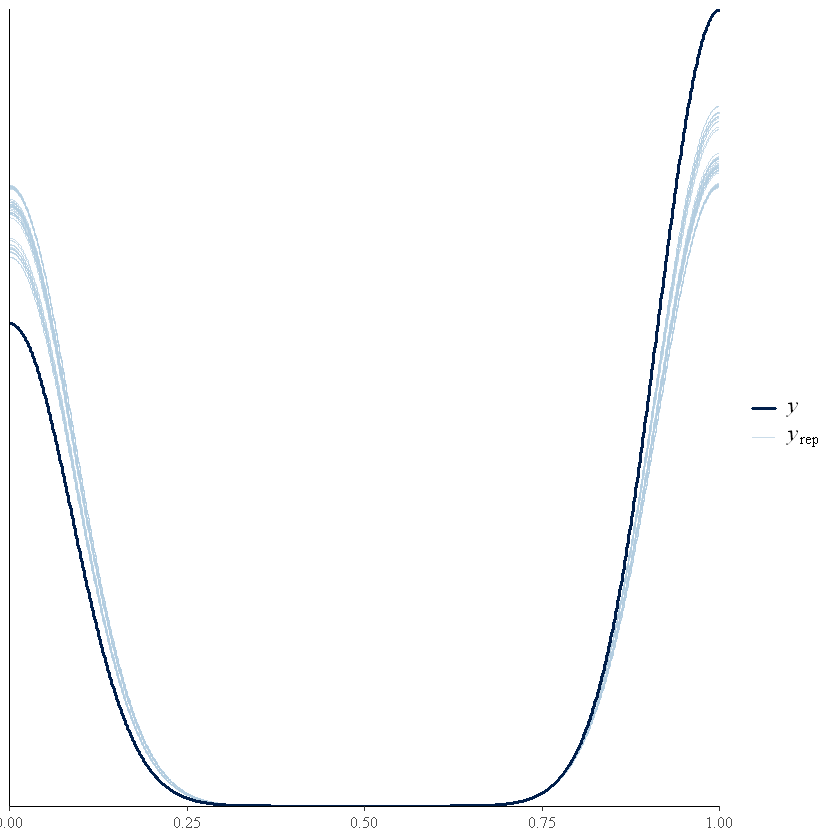

In [45]:
library(bayesplot)

pp_check(fit_bayes, type = "dens_overlay")